# Modeling — Customer Churn Prediction

Train, evaluate, and compare multiple ML models. Track everything with MLflow.

### Sections
1. Setup & Load Data
2. Build Full Pipelines
3. Baseline — Logistic Regression
4. XGBoost
5. LightGBM
6. Model Comparison
7. Hyperparameter Tuning (Best Model)
8. SHAP Explainability
9. Save Best Model

---
## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, sys, json, joblib

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, RocCurveDisplay,
    PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import mlflow
import mlflow.sklearn
import shap

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
TARGET = 'Churn'
print('Libraries loaded')

Libraries loaded


In [2]:
train_df = pd.read_csv('../data/processed/train.csv')
test_df  = pd.read_csv('../data/processed/test.csv')

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET]

# Load feature names
with open('../models/feature_names.json') as f:
    feature_info = json.load(f)

numeric_cols    = feature_info['numeric']
categorical_cols = feature_info['categorical']

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Churn rate — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}')

Train: (5634, 24) | Test: (1409, 24)
Churn rate — Train: 26.54% | Test: 26.54%


---
## 2. Build Preprocessing + SMOTE Pipeline

In [3]:
def build_pipeline(classifier):
    """Wrap a classifier in a full preprocessing + SMOTE pipeline."""
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ])
    return ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', classifier),
    ])


def evaluate_model(pipeline, X_test, y_test, model_name='Model'):
    """Print and return evaluation metrics."""
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    metrics = {
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
    }
    print(f'\n── {model_name} ──')
    for k, v in metrics.items():
        print(f'  {k:12s}: {v}')
    return metrics, y_pred, y_prob


print('Helper functions ready')

Helper functions ready


---
## 3. Baseline — Logistic Regression

In [4]:
lr_pipeline = build_pipeline(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)
lr_pipeline.fit(X_train, y_train)
lr_metrics, lr_pred, lr_prob = evaluate_model(lr_pipeline, X_test, y_test, 'Logistic Regression')

print('\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=['No Churn', 'Churn']))


── Logistic Regression ──
  ROC-AUC     : 0.8426
  F1          : 0.6227
  Precision   : 0.5168
  Recall      : 0.7834

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1035
       Churn       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



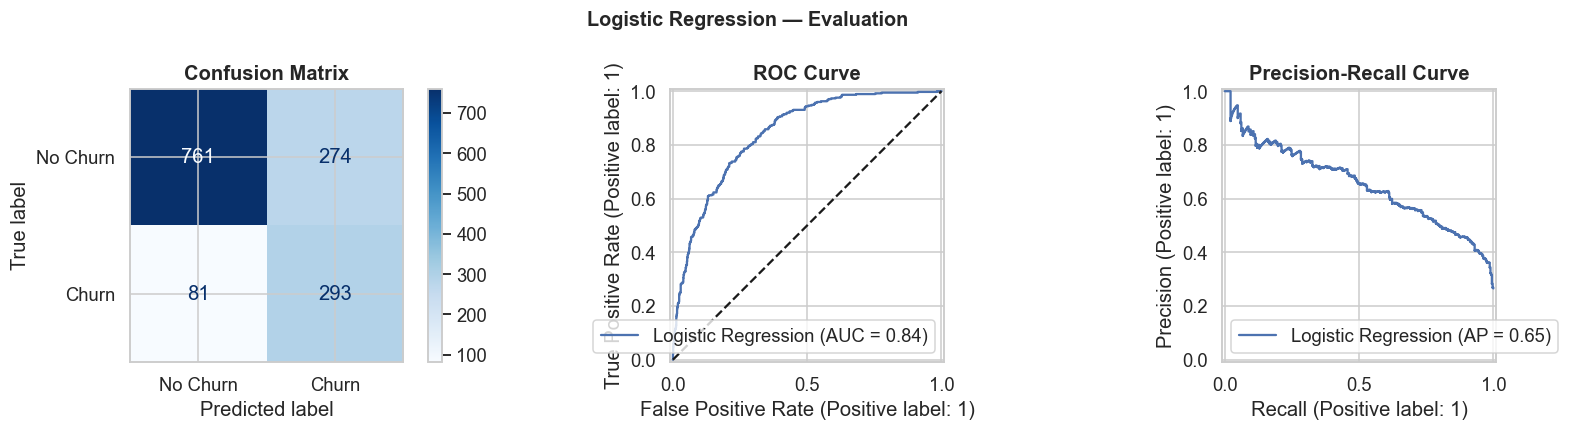

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred, display_labels=['No Churn', 'Churn'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontweight='bold')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, lr_prob, ax=axes[1], name='Logistic Regression')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].plot([0,1],[0,1],'k--')

# Precision-Recall
PrecisionRecallDisplay.from_predictions(y_test, lr_prob, ax=axes[2], name='Logistic Regression')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')

plt.suptitle('Logistic Regression — Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. XGBoost

In [6]:
xgb_pipeline = build_pipeline(
    XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0
    )
)
xgb_pipeline.fit(X_train, y_train)
xgb_metrics, xgb_pred, xgb_prob = evaluate_model(xgb_pipeline, X_test, y_test, 'XGBoost')

print('\nClassification Report:')
print(classification_report(y_test, xgb_pred, target_names=['No Churn', 'Churn']))


── XGBoost ──
  ROC-AUC     : 0.8381
  F1          : 0.5923
  Precision   : 0.5884
  Recall      : 0.5963

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.85      0.85      1035
       Churn       0.59      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



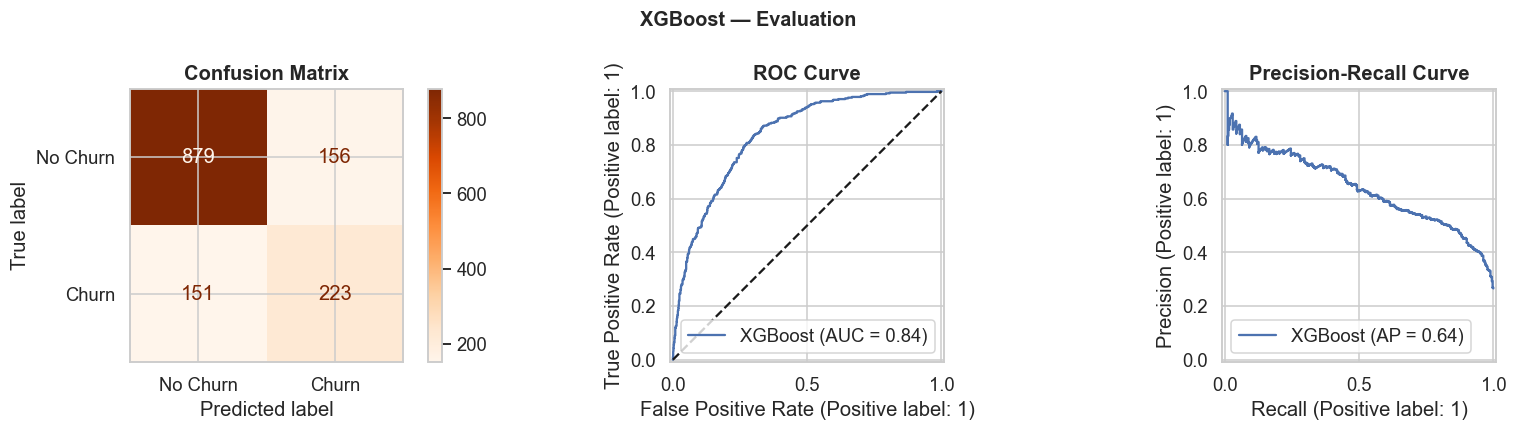

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, xgb_pred, display_labels=['No Churn', 'Churn'], cmap='Oranges', ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontweight='bold')
RocCurveDisplay.from_predictions(y_test, xgb_prob, ax=axes[1], name='XGBoost')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve', fontweight='bold')
PrecisionRecallDisplay.from_predictions(y_test, xgb_prob, ax=axes[2], name='XGBoost')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
plt.suptitle('XGBoost — Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. LightGBM

In [8]:
lgbm_pipeline = build_pipeline(
    LGBMClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, verbose=-1
    )
)
lgbm_pipeline.fit(X_train, y_train)
lgbm_metrics, lgbm_pred, lgbm_prob = evaluate_model(lgbm_pipeline, X_test, y_test, 'LightGBM')

print('\nClassification Report:')
print(classification_report(y_test, lgbm_pred, target_names=['No Churn', 'Churn']))


── LightGBM ──
  ROC-AUC     : 0.837
  F1          : 0.5884
  Precision   : 0.5807
  Recall      : 0.5963

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.85      1035
       Churn       0.58      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



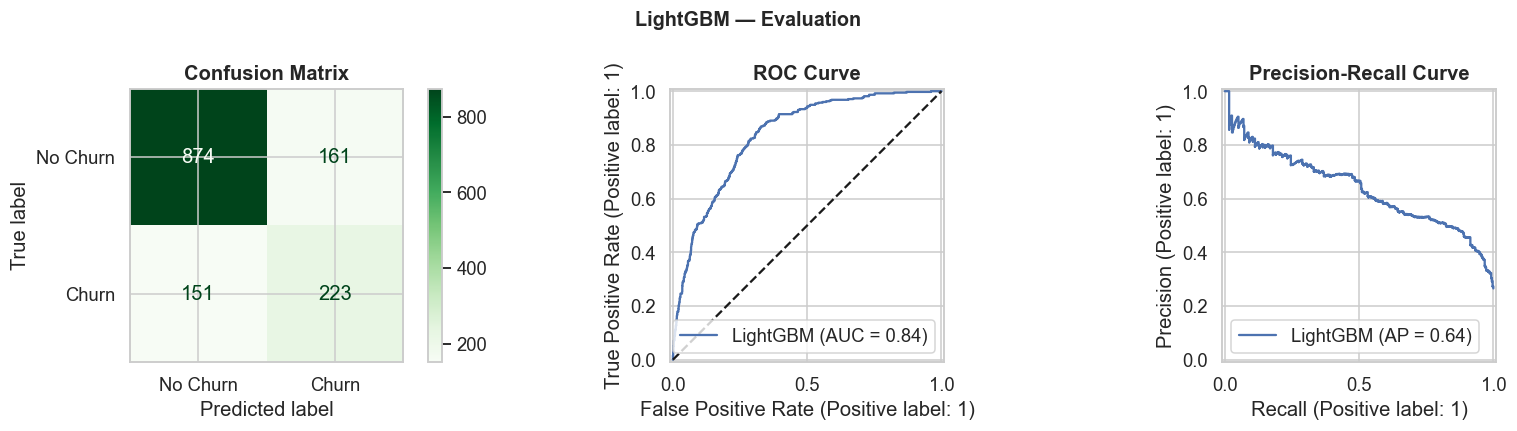

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, lgbm_pred, display_labels=['No Churn', 'Churn'], cmap='Greens', ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontweight='bold')
RocCurveDisplay.from_predictions(y_test, lgbm_prob, ax=axes[1], name='LightGBM')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve', fontweight='bold')
PrecisionRecallDisplay.from_predictions(y_test, lgbm_prob, ax=axes[2], name='LightGBM')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
plt.suptitle('LightGBM — Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Model Comparison

In [11]:
results = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'XGBoost':             xgb_metrics,
    'LightGBM':            lgbm_metrics,
}).T.sort_values('ROC-AUC', ascending=False)

print('Model Comparison')
results.style.background_gradient(cmap='RdYlGn', axis=0).format('{:.4f}')

Model Comparison


,ROC-AUC,F1,Precision,Recall
Logistic Regression,0.8426,0.6227,0.5168,0.7834
XGBoost,0.8381,0.5923,0.5884,0.5963
LightGBM,0.8370,0.5884,0.5807,0.5963


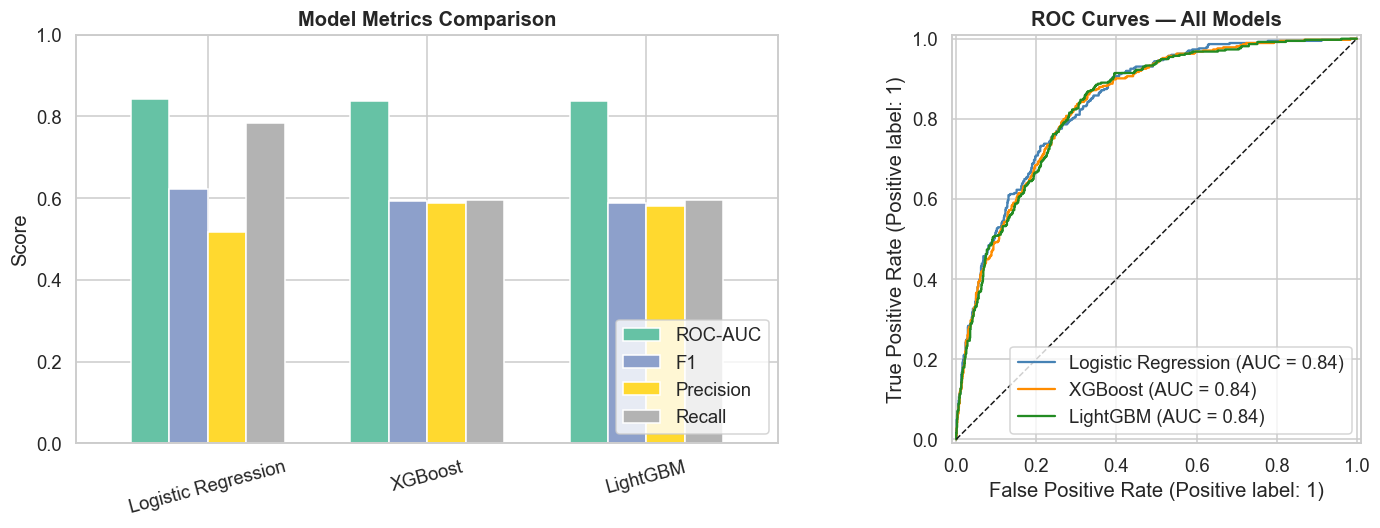


 Best model: Logistic Regression (ROC-AUC = 0.8426)


In [12]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of metrics
results.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', width=0.7)
axes[0].set_title('Model Metrics Comparison', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(loc='lower right')

# ROC curves all on one chart
for prob, name, color in [
    (lr_prob,   'Logistic Regression', 'steelblue'),
    (xgb_prob,  'XGBoost',             'darkorange'),
    (lgbm_prob, 'LightGBM',            'forestgreen'),
]:
    RocCurveDisplay.from_predictions(y_test, prob, ax=axes[1], name=name, color=color)
axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_title('ROC Curves — All Models', fontweight='bold')

plt.tight_layout()
plt.show()

best_model_name = results['ROC-AUC'].idxmax()
print(f'\n Best model: {best_model_name} (ROC-AUC = {results.loc[best_model_name, "ROC-AUC"]})')

---
## 7. Hyperparameter Tuning (Best Model)

In [13]:
from sklearn.model_selection import RandomizedSearchCV

# Tune XGBoost (swap for LightGBM if it won above)
param_dist = {
    'classifier__n_estimators':    [100, 200, 300],
    'classifier__max_depth':       [3, 4, 5, 6],
    'classifier__learning_rate':   [0.01, 0.05, 0.1],
    'classifier__subsample':       [0.7, 0.8, 0.9],
    'classifier__colsample_bytree':[0.7, 0.8, 0.9],
    'classifier__min_child_weight':[1, 3, 5],
}

base_pipeline = build_pipeline(
    XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0)
)

search = RandomizedSearchCV(
    base_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print('Running RandomizedSearchCV (20 iterations × 5 folds)...')
search.fit(X_train, y_train)
print(f'\nBest ROC-AUC (CV): {search.best_score_:.4f}')
print(f'Best params: {search.best_params_}')

Running RandomizedSearchCV (20 iterations × 5 folds)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best ROC-AUC (CV): 0.8471
Best params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 100, 'classifier__min_child_weight': 5, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}


In [14]:
# Evaluate tuned model
best_pipeline = search.best_estimator_
tuned_metrics, tuned_pred, tuned_prob = evaluate_model(
    best_pipeline, X_test, y_test, 'XGBoost (Tuned)'
)

print('\nImprovement over default XGBoost:')
for metric in ['ROC-AUC', 'F1', 'Precision', 'Recall']:
    diff = tuned_metrics[metric] - xgb_metrics[metric]
    arrow = '▲' if diff > 0 else '▼'
    print(f'  {metric:12s}: {arrow} {abs(diff):.4f}')


── XGBoost (Tuned) ──
  ROC-AUC     : 0.8429
  F1          : 0.6129
  Precision   : 0.564
  Recall      : 0.6711

Improvement over default XGBoost:
  ROC-AUC     : ▲ 0.0048
  F1          : ▲ 0.0206
  Precision   : ▼ 0.0244
  Recall      : ▲ 0.0748


---
## 8. SHAP Explainability

In [16]:
# Use LightGBM for SHAP (compatible with shap 0.49.1)
preprocessor_fitted = lgbm_pipeline.named_steps['preprocessor']
classifier_fitted   = lgbm_pipeline.named_steps['classifier']

# Transform test data
X_test_transformed = preprocessor_fitted.transform(X_test)

# Get encoded feature names
ohe_features = preprocessor_fitted.named_transformers_['cat']['onehot']\
                                  .get_feature_names_out(categorical_cols).tolist()
all_feature_names = numeric_cols + ohe_features

# SHAP values
explainer = shap.TreeExplainer(classifier_fitted)
shap_values = explainer.shap_values(X_test_transformed)

# LightGBM returns list for binary classification — take class 1
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f'SHAP computed for {X_test_transformed.shape[0]} test samples')

SHAP computed for 1409 test samples


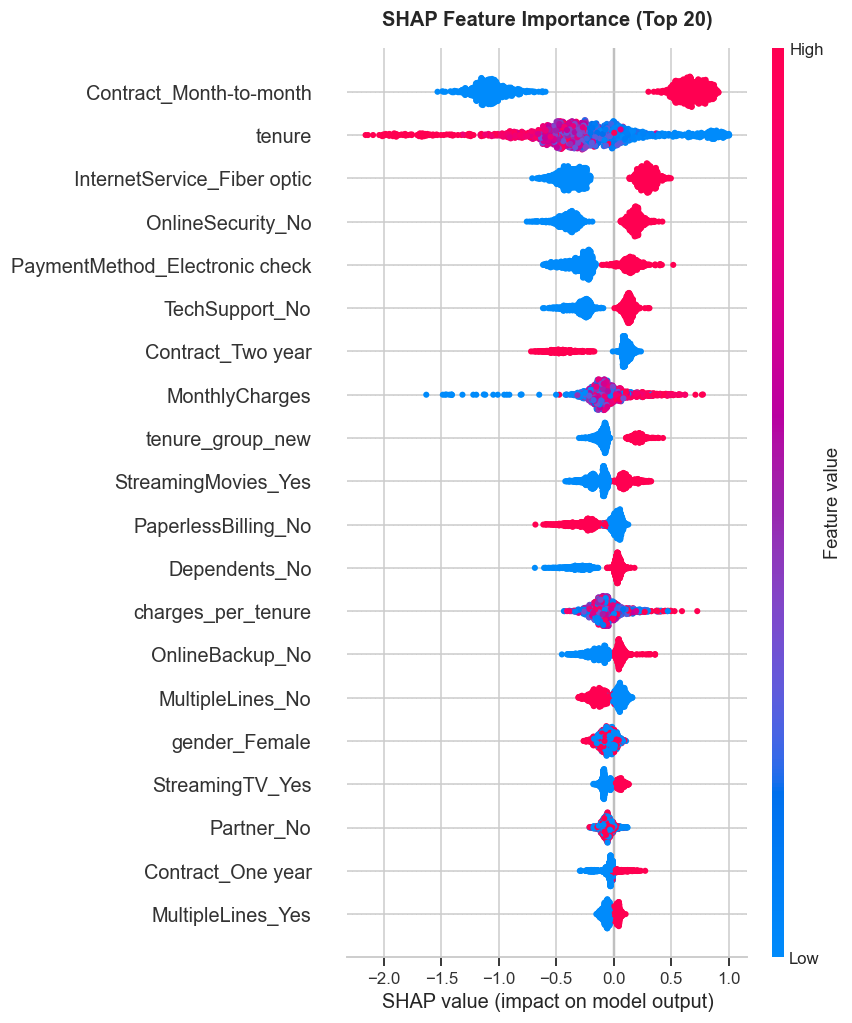

In [17]:
# Summary plot — global feature importance
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=all_feature_names,
    max_display=20, show=False
)
plt.title('SHAP Feature Importance (Top 20)', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

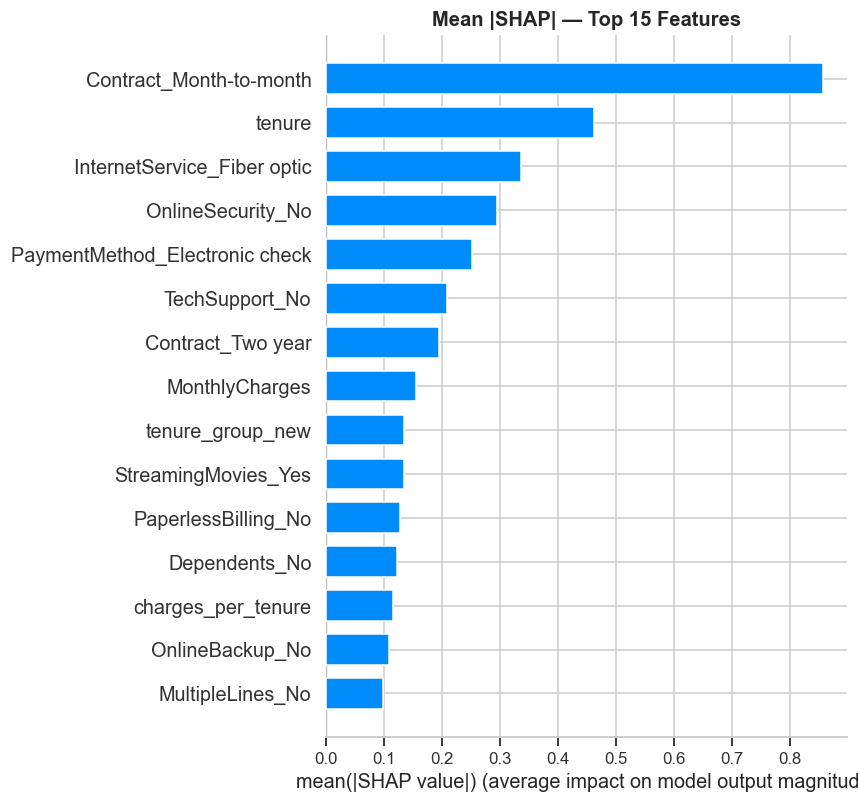

In [18]:
# Bar plot — mean absolute SHAP values
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=all_feature_names,
    plot_type='bar', max_display=15, show=False
)
plt.title('Mean |SHAP| — Top 15 Features', fontweight='bold')
plt.tight_layout()
plt.show()

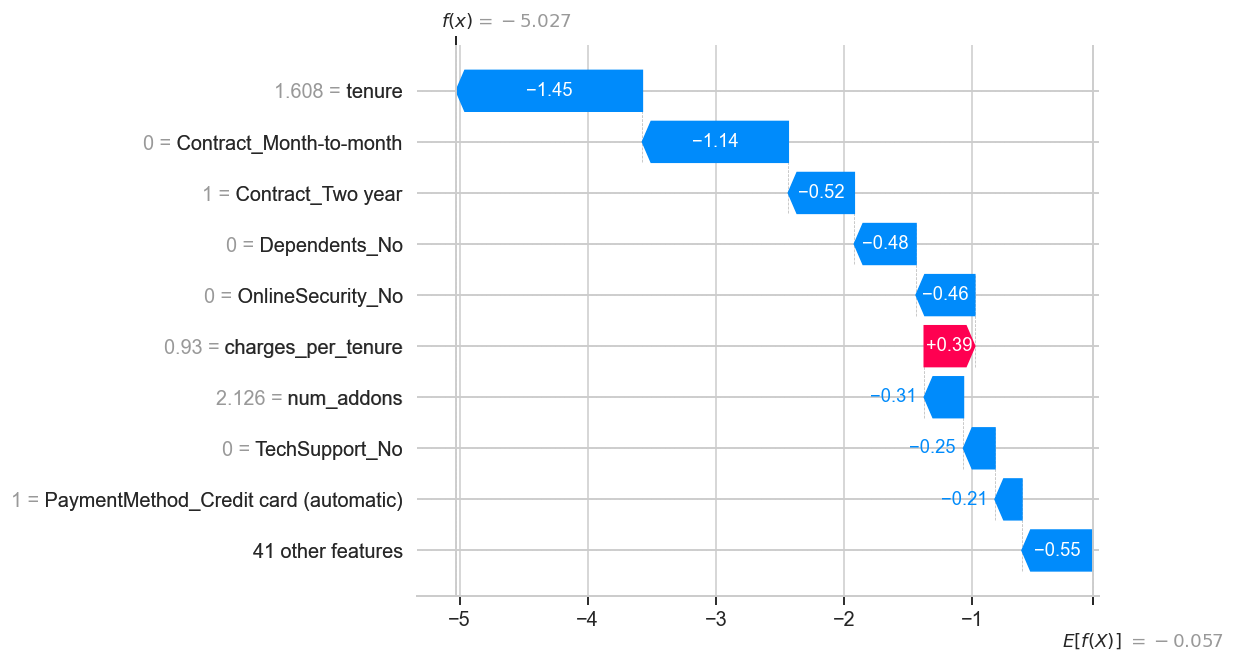


Actual label: 0 | Predicted prob: 4.72%


In [19]:
# Waterfall plot — single prediction explanation
sample_idx = 0
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test_transformed[sample_idx],
        feature_names=all_feature_names
    )
)
print(f'\nActual label: {y_test.iloc[sample_idx]} | Predicted prob: {tuned_prob[sample_idx]:.2%}')

---
## 9. MLflow Tracking + Save Best Model

In [20]:
os.makedirs('../mlflow', exist_ok=True)
mlflow.set_tracking_uri('../mlflow')
mlflow.set_experiment('churn-prediction')

models_to_log = [
    ('Logistic Regression', lr_pipeline, lr_metrics, lr_prob),
    ('XGBoost',             xgb_pipeline, xgb_metrics, xgb_prob),
    ('LightGBM',            lgbm_pipeline, lgbm_metrics, lgbm_prob),
    ('XGBoost_Tuned',       best_pipeline, tuned_metrics, tuned_prob),
]

for name, pipeline, metrics, prob in models_to_log:
    with mlflow.start_run(run_name=name):
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(pipeline, artifact_path='model')
        print(f'Logged: {name}')

print('\n All runs logged to MLflow.')
print('   View UI: run `mlflow ui --backend-store-uri ../mlflow` in terminal')

2026/05/11 10:58:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 10:58:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 10:58:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged: Logistic Regression


2026/05/11 10:58:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 10:58:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged: XGBoost


2026/05/11 10:58:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 10:58:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged: LightGBM


2026/05/11 10:58:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged: XGBoost_Tuned

 All runs logged to MLflow.
   View UI: run `mlflow ui --backend-store-uri ../mlflow` in terminal


In [21]:
os.makedirs('../models', exist_ok=True)
joblib.dump(best_pipeline, '../models/best_model_pipeline.pkl')
print('Best model saved to models/best_model_pipeline.pkl')

# Final summary
final_results = results.copy()
final_results.loc['XGBoost (Tuned)'] = tuned_metrics
print('\n=== Final Model Leaderboard ===')
print(final_results.sort_values('ROC-AUC', ascending=False).to_string())

Best model saved to models/best_model_pipeline.pkl

=== Final Model Leaderboard ===
                     ROC-AUC      F1  Precision  Recall
XGBoost (Tuned)       0.8429  0.6129     0.5640  0.6711
Logistic Regression   0.8426  0.6227     0.5168  0.7834
XGBoost               0.8381  0.5923     0.5884  0.5963
LightGBM              0.8370  0.5884     0.5807  0.5963


## MODELING SUMMARY

---

## MODELS TRAINED

### Logistic Regression
- Used as the baseline model.

### XGBoost
- Trained with:
  - Default parameters
  - Tuned hyperparameters

### LightGBM
- Trained using default settings.

---

## PIPELINE

```python
Preprocessor → SMOTE → Classifier
```

Pipeline flow:
1. Data preprocessing
2. Class balancing with SMOTE
3. Model training

---

## TUNING

```python
RandomizedSearchCV(
    n_iter=20,
    cv=StratifiedKFold(n_splits=5)
)
```

- Randomized hyperparameter search
- 5-fold stratified cross-validation

---

## EXPLAINABILITY

### SHAP TreeExplainer
Used for:
- Global feature importance
- Individual prediction explanations

This helps explain:
- Why customers churn
- Which features influence model predictions

---

## TRACKING

- All experiments and runs logged using MLflow

Tracked components include:
- Parameters
- Metrics
- Artifacts
- Model versions

---

# NEXT STEP → FASTAPI DEPLOYMENT

## Deployment Tasks

### 1. API Integration

```python
api/main.py
```

- Wrap `best_model_pipeline.pkl` inside the FastAPI application.

### 2. Streamlit Testing
- Build a Streamlit interface for interactive predictions.

### 3. Docker Containerization
- Containerize the application using Docker for portability and deployment.